In [8]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
from typing import Any

from feature_extractor import GeometricFeatureExtractor
from icp import ICP, MultiStartICP, MultiSeedSyntheticICPResult, fit_multi_seed
from matcher import NearestNeighborMatcher
from visualization import ErrorMetricsVisualizer

plt.style.use('seaborn-v0_8-whitegrid')

MAX_ITER = 200
N_SEEDS = 5
N_STARTS = 13
DROPOUT_PROBS = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

In [9]:
extractor = GeometricFeatureExtractor(k=4)
matcher = NearestNeighborMatcher(feature_extractor=extractor)
single_icp = ICP(matcher=matcher, max_iter=MAX_ITER)
icp = MultiStartICP(single_icp, n_starts=N_STARTS)

In [10]:
results: list[MultiSeedSyntheticICPResult] = []
for dropout_prob in DROPOUT_PROBS:
    experiment_kwargs: dict[str, Any] = {"n": 500, "noise_std": 0.0, "t_scale": 8.0, "style": "clustered"}
    result = fit_multi_seed(icp, seeds=list(range(N_SEEDS)), dropout_prob=dropout_prob, verbose=True, experiment_kwargs=experiment_kwargs)
    results.append(result)

Solving 5 seeds: 100%|██████████| 5/5 [00:02<00:00,  1.89it/s]


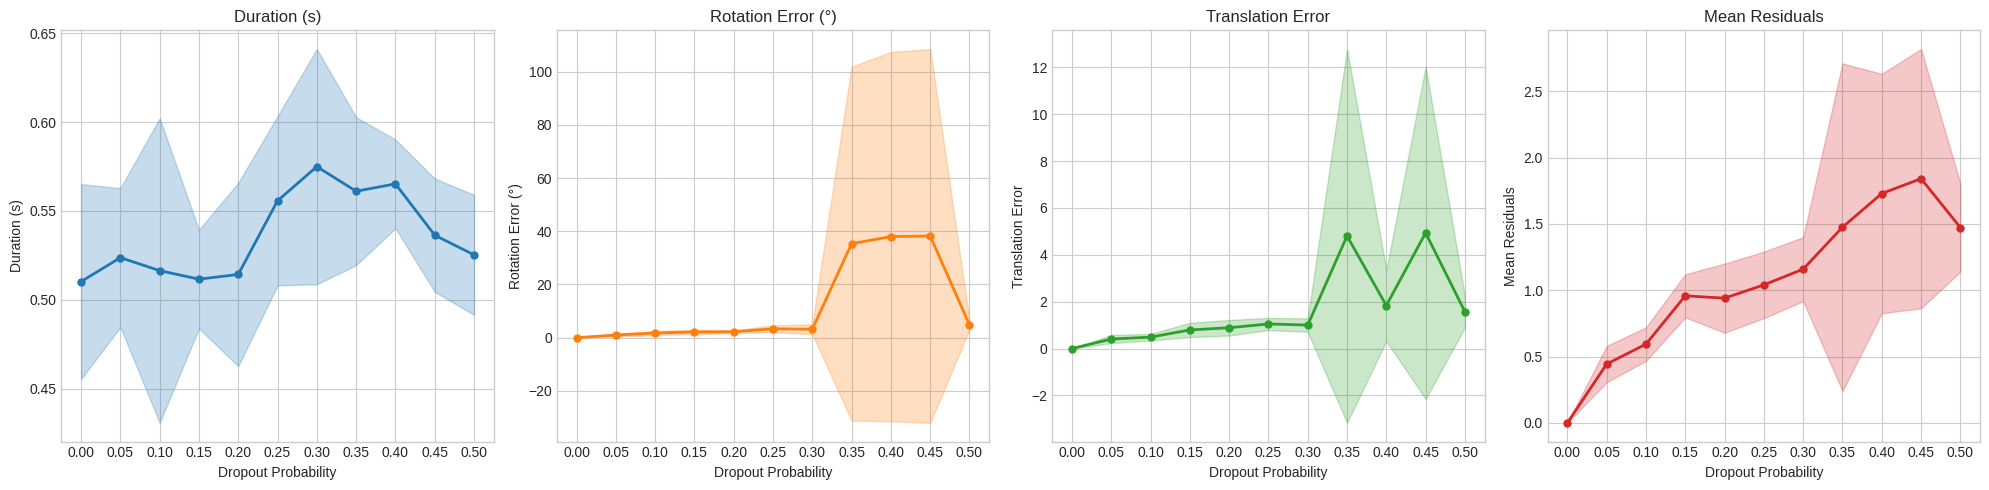

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
ErrorMetricsVisualizer.plot_parameter_sweep(
    axes=axes,
    data_per_metric=[np.array([result.durations_s for result in results]), np.array([result.rotation_errors for result in results]), np.array([result.translation_errors for result in results]), np.array([result.mean_residuals for result in results])],
    y_labels=['Duration (s)', 'Rotation Error (°)', 'Translation Error', 'Mean Residuals'],
    x_label='Dropout Probability',
    x = DROPOUT_PROBS,
)
plt.tight_layout()
plt.savefig('../results/10_incomplete_observation.png', dpi=300)
plt.show()